# Movie Rental Duration Prediction

## Business Problem

A movie rental company wants to better understand how long customers keep rented movies before returning them.

Predicting rental duration can help the company:
- manage inventory availability,
- understand customer rental behavior,
- plan pricing or recommendation strategies,
- improve operational decisions.

The goal of this project is to build a regression model that predicts the number of days a movie will be rented based on customer, movie, and rental information.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso, LinearRegression

In [3]:

# Read data
rental_info = pd.read_csv("rental_info.csv")

# Convert dates
rental_info["rental_date"] = pd.to_datetime(rental_info["rental_date"])
rental_info["return_date"] = pd.to_datetime(rental_info["return_date"])

# Create target column
rental_info["rental_length_days"] = (
    rental_info["return_date"] - rental_info["rental_date"]
).dt.days


In [4]:

# Create dummy variables
rental_info["deleted_scenes"] = np.where(
    rental_info["special_features"].str.contains("Deleted Scenes"),
    1,
    0
)

rental_info["behind_the_scenes"] = np.where(
    rental_info["special_features"].str.contains("Behind the Scenes"),
    1,
    0
)

# Create X and y
X = rental_info.drop(
    ["rental_length_days", "rental_date", "return_date", "special_features"],
    axis=1
)

y = rental_info["rental_length_days"]

In [5]:

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=9
)

# Feature selection with Lasso
lasso = Lasso(alpha=0.01, random_state=9)
lasso.fit(X_train, y_train)

X_train_selected = X_train.loc[:, lasso.coef_ != 0]
X_test_selected = X_test.loc[:, lasso.coef_ != 0]


In [6]:

# Final model
best_model = LinearRegression()
best_model.fit(X_train_selected, y_train)

# Calculate MSE
predictions = best_model.predict(X_test_selected)
best_mse = mean_squared_error(y_test, predictions)

best_mse


2.9397601796848924

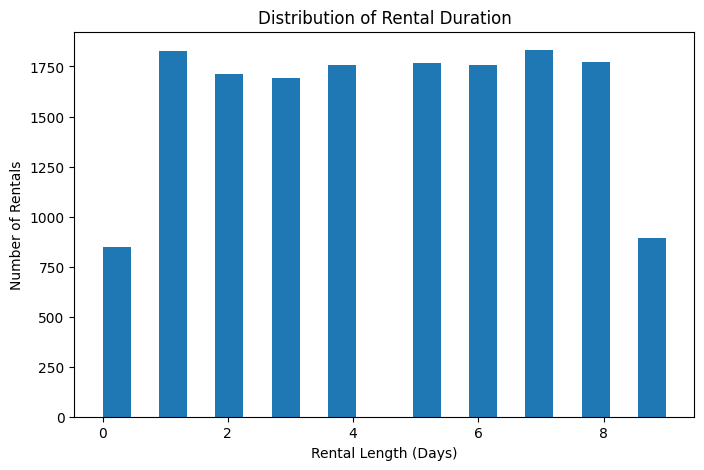

In [7]:

plt.figure(figsize=(8, 5))
plt.hist(rental_info["rental_length_days"], bins=20)
plt.xlabel("Rental Length (Days)")
plt.ylabel("Number of Rentals")
plt.title("Distribution of Rental Duration")
plt.show()

The distribution of rental duration is relatively uniform across most rental periods. Rentals between 1 and 8 days occur at similar frequencies, while very short (0 days) and very long (9 days) rentals are less common.

In [14]:
rating_df = pd.DataFrame(
    list(rating_avg.items()),
    columns=["Rating", "Average Rental Duration"]
)

rating_df

,Rating,Average Rental Duration
0,PG,4.483475
1,PG-13,4.576065
2,R,4.483820
3,NC-17,4.530009


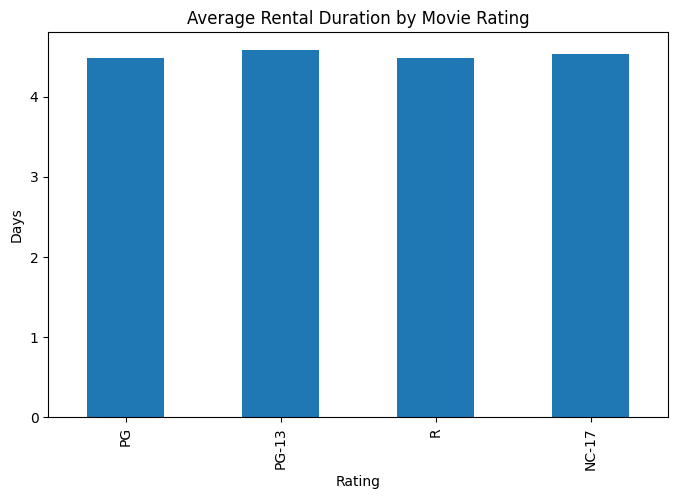

In [15]:
rating_df.plot(
    x="Rating",
    y="Average Rental Duration",
    kind="bar",
    legend=False,
    figsize=(8,5)
)

plt.title("Average Rental Duration by Movie Rating")
plt.ylabel("Days")
plt.show()

In [17]:
rate_duration = (
    rental_info
    .groupby("rental_rate")["rental_length_days"]
    .mean()
    .reset_index()
)

rate_duration

,rental_rate,rental_length_days
0,0.99,4.527230
1,2.99,4.530330
2,4.99,4.520314


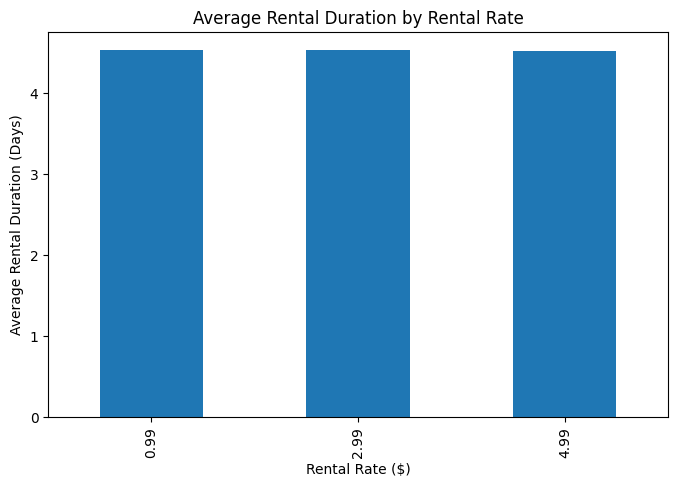

In [18]:
rate_duration.plot(
    x="rental_rate",
    y="rental_length_days",
    kind="bar",
    legend=False,
    figsize=(8,5)
)

plt.title("Average Rental Duration by Rental Rate")
plt.xlabel("Rental Rate ($)")
plt.ylabel("Average Rental Duration (Days)")
plt.show()

#### Average Rental Duration by Rental Rate

Rental duration remains almost constant across all rental rate categories. Movies priced at $0.99, $2.99, and $4.99 are rented for approximately 4.5 days on average. This suggests that rental price alone does not have a meaningful impact on how long customers keep rentals.

In [20]:
rental_info["length"].describe()

count    15861.000000
mean       114.994578
std         40.114715
min         46.000000
25%         81.000000
50%        114.000000
75%        148.000000
max        185.000000
Name: length, dtype: float64

Let's investigate:

Do longer movies tend to be rented for longer periods?

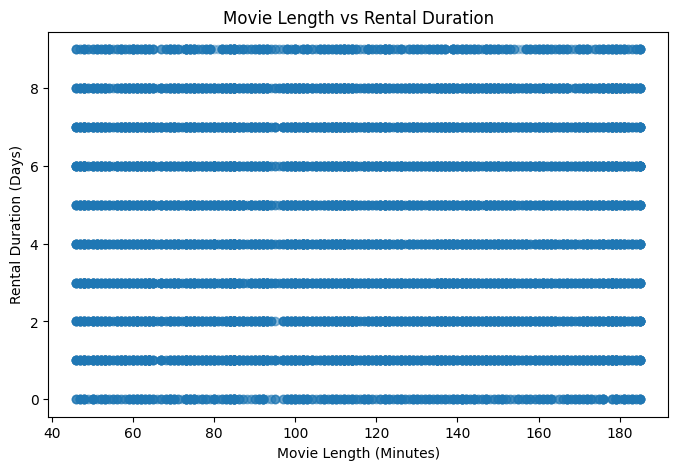

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(
    rental_info["length"],
    rental_info["rental_length_days"],
    alpha=0.3
)

plt.xlabel("Movie Length (Minutes)")
plt.ylabel("Rental Duration (Days)")
plt.title("Movie Length vs Rental Duration")

plt.show()

In [22]:
rental_info[["length", "rental_length_days"]].corr()

,length,rental_length_days
length,1.000000,-0.004547
rental_length_days,-0.004547,1.000000
